In [5]:
!pip install larq

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 65 kB 2.4 MB/s 
  Attempting uninstall: importlib-metadata
    Found existing installation: importlib-metadata 4.13.0
    Uninstalling importlib-metadata-4.13.0:
      Successfully uninstalled importlib-metadata-4.13.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
markdown 3.4.1 requires importlib-metadata>=4.4; python_version < "3.10", but you have importlib-metadata 3.10.1 which is incompatible.
gym 0.25.2 requires importlib-metadata>=4.8.0; python_version < "3.10", but you have importlib-metadata 3.10.1 which is incompatible.


In [6]:
import tensorflow as tf
import larq as lq

In [7]:
# Download dataset MNIST
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

# Divisione delle immagini per addestramento e validazione
train_images = train_images.reshape((60000, 28, 28, 1))
test_images = test_images.reshape((10000, 28, 28, 1))

# Normalizzazione pixel delle immagini
train_images, test_images = train_images / 175.5 - 1, test_images / 175.5 - 1 

11490434/11490434 [==============================] - 0s 0us/step


# 1. Analisi singola Binarized Neural Network (BNN)
A seguire e' riportato il codice per l'implementazione di una singola Rete Neurale Binarizzata. 



In [ ]:
# Parametri per layer binarizzati 
kwargs = dict(input_quantizer="ste_sign",
              kernel_quantizer="ste_sign",
              kernel_constraint="weight_clip")

# Modello rete binarizzata (2 hidden layer, 1 output layer)
# Input layer: binarizzato solo nelle attivazioni 
# 1 hidden layer (32 neuroni): pesi e attivazioni binarizzate
# 2 hidden layer (16 neuroni): pesi e attivazioni binarizzate
# Output layer: 10 neuroni, uno per ogni classe da predire  
model = tf.keras.models.Sequential()

model.add(tf.keras.layers.Flatten())
model.add(lq.layers.QuantDense(32, **kwargs,
                               input_shape=(28, 28, 1)))
model.add(tf.keras.layers.BatchNormalization(momentum=0.99, scale=False))

model.add(lq.layers.QuantDense(16, **kwargs))
model.add(tf.keras.layers.BatchNormalization(momentum=0.99, scale=False))

model.add(lq.layers.QuantDense(10, **kwargs))
model.add(tf.keras.layers.BatchNormalization(momentum=0.99, scale=False))
model.add(tf.keras.layers.Activation("softmax"))

In [ ]:
# Configurazione algoritmo di ottimizzazione, funzione di costo e metrica
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics="accuracy")

# Fitting della rete binarizzata
history = model.fit(train_images, train_labels, batch_size=128, 
                    epochs=150, validation_data=(test_images, test_labels))

# Validazione del modello con le immagini del test set
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"Test accuracy {test_acc * 100:.2f} %\n")

Epoch 1/150
469/469 [==============================] - 4s 6ms/step - loss: 1.2083 - accuracy: 0.6944 - val_loss: 1.0169 - val_accuracy: 0.7789
Epoch 2/150
469/469 [==============================] - 3s 6ms/step - loss: 0.9292 - accuracy: 0.8093 - val_loss: 0.9638 - val_accuracy: 0.7998
Epoch 3/150
469/469 [==============================] - 3s 6ms/step - loss: 0.8758 - accuracy: 0.8213 - val_loss: 0.8279 - val_accuracy: 0.8412
Epoch 4/150
469/469 [==============================] - 3s 5ms/step - loss: 0.8559 - accuracy: 0.8256 - val_loss: 0.8741 - val_accuracy: 0.8260
Epoch 5/150
469/469 [==============================] - 3s 6ms/step - loss: 0.8464 - accuracy: 0.8291 - val_loss: 0.8302 - val_accuracy: 0.8275
Epoch 6/150
469/469 [==============================] - 3s 7ms/step - loss: 0.8329 - accuracy: 0.8316 - val_loss: 0.8476 - val_accuracy: 0.8341
Epoch 7/150
469/469 [==============================] - 3s 6ms/step - loss: 0.8267 - accuracy: 0.8337 - val_loss: 0.8700 - val_accuracy: 0.8196

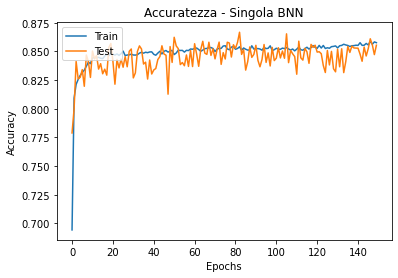

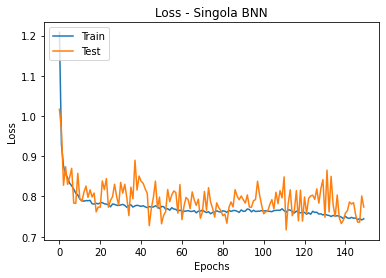

In [ ]:
import matplotlib.pyplot as plt

# Plot curva accuratezza
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuratezza - Singola BNN')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot della curva loss 
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss - Singola BNN')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

1/1 [==============================] - 0s 26ms/step


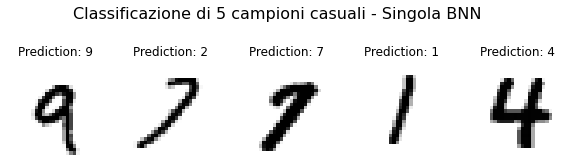

In [ ]:
import numpy as np
import random

# Risultati della classificazione di 4 campioni casuali
sampled_imgs_index = random.sample(range(1, len(test_images)), 5)
sampled_imgs = []

for sample in sampled_imgs_index:
  sampled_imgs.append(test_images[sample])

predicted_imgs = model.predict(np.array(sampled_imgs))

fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(10, 3))
fig.suptitle("Classificazione di 5 campioni casuali - Singola BNN", fontsize=16)
for ax, image, prediction in zip(axes, sampled_imgs, predicted_imgs):
  ax.set_axis_off()
  image = image.reshape(28, 28)
  ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
  ax.set_title(f"Prediction: {np.argmax(prediction)}")

313/313 [==============================] - 1s 2ms/step


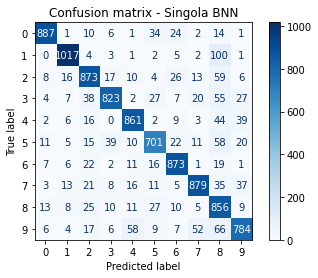

In [ ]:
# Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Classificazione delle immagini e conversione label
predicted_images = model.predict(test_images)
predicted_labels = np.argmax(predicted_images, axis=1)

cm = confusion_matrix(test_labels, predicted_labels)
cm_fig = ConfusionMatrixDisplay(confusion_matrix=cm)

cm_fig.plot(cmap=plt.cm.Blues)
cm_fig.ax_.set_title("Confusion matrix - Singola BNN")
plt.show()

In [ ]:
# Salvataggio dei pesi binarizzati e non binarizzati
model.save("full_precision_model.h5")  
fp_weights = model.get_weights()  

with lq.context.quantized_scope(True):
  model.save("binary_model.h5")  
  weights = model.get_weights()  

In [ ]:
# Struttura della rete e statistiche 
lq.models.summary(model)

+sequential stats----------------------------------------------------------------------+
| Layer                  Input prec.    Outputs  # 1-bit  # 32-bit  Memory  1-bit MACs |
|                              (bit)                 x 1       x 1    (kB)             |
+--------------------------------------------------------------------------------------+
| flatten                          -  (-1, 784)        0         0       0           0 |
| quant_dense                      1   (-1, 32)    25088        32    3.19       25088 |
| batch_normalization              -   (-1, 32)        0        64    0.25           0 |
| quant_dense_1                    1   (-1, 16)      512        16    0.12         512 |
| batch_normalization_1            -   (-1, 16)        0        32    0.12           0 |
| quant_dense_2                    1   (-1, 10)      160        10    0.06         160 |
| batch_normalization_2            -   (-1, 10)        0        20    0.08           0 |
| activation         

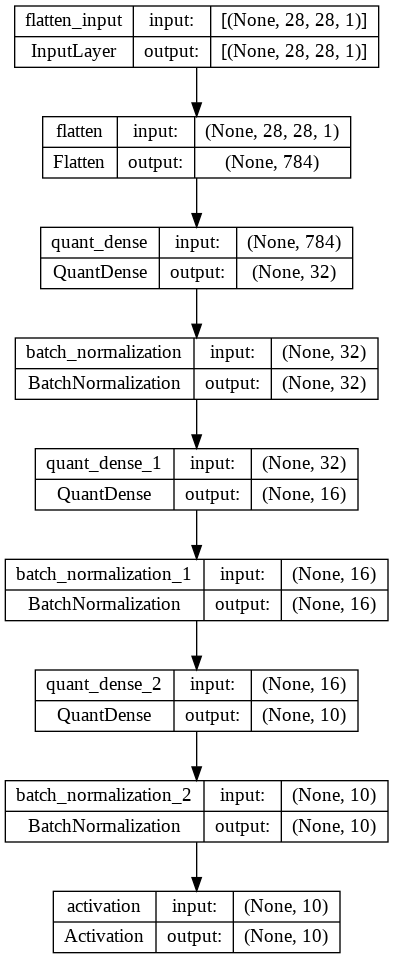

In [ ]:
# Modello rete binarizzata
tf.keras.utils.plot_model(model, "single_bnn.png", show_shapes=True)

# 2. Analisi singole Deep Neural Network (DNN e BNN)
A seguire e' riportato il codice per l'implementazione di una Rete Neurale non binarizzata e di una Rete Neurale Binarizzata con piu' paramentri della precedente. 

In [ ]:
# Architettura rete non binarizzata
model_dnn = tf.keras.Sequential([
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu", input_shape=(28, 28, 1)),
    tf.keras.layers.Dense(64, activation="relu"),
    #tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax"),
])

# Architettura rete binarizzata
model_bnn = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(),
    lq.layers.QuantDense(64, **kwargs, input_shape=(28, 28, 1)),
    tf.keras.layers.BatchNormalization(momentum=0.99, scale=False),
    lq.layers.QuantDense(64, **kwargs),
    tf.keras.layers.BatchNormalization(momentum=0.99, scale=False),
    #lq.layers.QuantDense(32, **kwargs),
    #tf.keras.layers.BatchNormalization(momentum=0.99, scale=False),
    lq.layers.QuantDense(10, **kwargs),
    tf.keras.layers.BatchNormalization(momentum=0.99, scale=False),
    tf.keras.layers.Activation("softmax")
])

# Configurazione algoritmo di ottimizzazione, funzione di costo e metrica
model_dnn.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics="accuracy")

model_bnn.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics="accuracy")

# Fitting della rete binarizzata e non binarizzata
history_dnn = model_dnn.fit(train_images, train_labels, batch_size=128, 
                            epochs=150, validation_data=(test_images, test_labels))

print(f"DNN Training: OK!\n")

history_bnn = model_bnn.fit(train_images, train_labels, batch_size=128, 
                            epochs=150, validation_data=(test_images, test_labels))

print(f"BNN Training: OK!\n")

# Validazione dei modelli con le immagini del test set
test_loss_dnn, test_acc_dnn = model_dnn.evaluate(test_images, test_labels)
test_loss_bnn, test_acc_bnn = model_bnn.evaluate(test_images, test_labels)
print(f"DNN - Test accuracy {test_acc_dnn * 100:.2f} %\n")
print(f"BNN - Test accuracy {test_acc_bnn * 100:.2f} %\n")

Epoch 1/150
469/469 [==============================] - 2s 4ms/step - loss: 0.5080 - accuracy: 0.8511 - val_loss: 0.2866 - val_accuracy: 0.9169
Epoch 2/150
469/469 [==============================] - 1s 3ms/step - loss: 0.2634 - accuracy: 0.9214 - val_loss: 0.2177 - val_accuracy: 0.9328
Epoch 3/150
469/469 [==============================] - 1s 3ms/step - loss: 0.2121 - accuracy: 0.9364 - val_loss: 0.1962 - val_accuracy: 0.9407
Epoch 4/150
469/469 [==============================] - 2s 3ms/step - loss: 0.1735 - accuracy: 0.9482 - val_loss: 0.1711 - val_accuracy: 0.9483
Epoch 5/150
469/469 [==============================] - 2s 3ms/step - loss: 0.1525 - accuracy: 0.9531 - val_loss: 0.1412 - val_accuracy: 0.9566
Epoch 6/150
469/469 [==============================] - 1s 3ms/step - loss: 0.1372 - accuracy: 0.9584 - val_loss: 0.1367 - val_accuracy: 0.9586
Epoch 7/150
469/469 [==============================] - 2s 3ms/step - loss: 0.1247 - accuracy: 0.9616 - val_loss: 0.1261 - val_accuracy: 0.9605

In [ ]:
# Salvataggio dei modelli 
model_dnn.save("large_dnn")
model_bnn.save("full_precision_large_bnn.h5")  
fp_weights = model_bnn.get_weights()  

with lq.context.quantized_scope(True):
  model_bnn.save("binary_large_bnn.h5")  
  weights = model_bnn.get_weights()  

Text(0.5, 1.0, 'BNN')

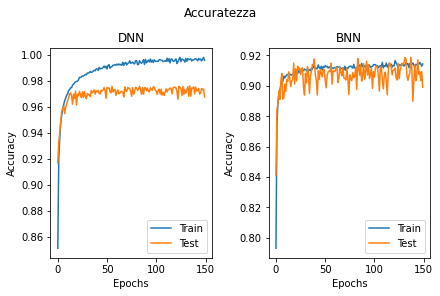

In [ ]:
# Confronto accuratezza delle due reti 
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True)

fig.suptitle("Accuratezza")

# Plot curva accuratezza
ax1.plot(history_dnn.history['accuracy'])
ax1.plot(history_dnn.history['val_accuracy'])
ax1.set(xlabel="Epochs", ylabel="Accuracy")
ax1.legend(['Train', 'Test'], loc='best')
ax1.set_title("DNN")

ax2.plot(history_bnn.history['accuracy'])
ax2.plot(history_bnn.history['val_accuracy'])
ax2.set(xlabel="Epochs", ylabel="Accuracy")
ax2.legend(['Train', 'Test'], loc='best')
ax2.set_title("BNN")

Text(0.5, 1.0, 'BNN')

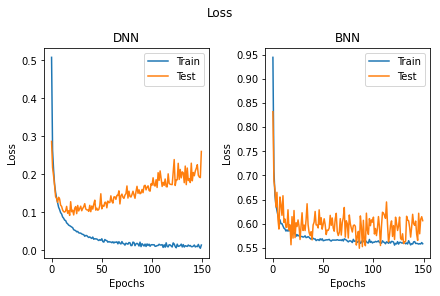

In [ ]:
# Confronto loss delle due reti
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True)

fig.suptitle("Loss")

# Plot curva accuratezza
ax1.plot(history_dnn.history['loss'])
ax1.plot(history_dnn.history['val_loss'])
ax1.set(xlabel="Epochs", ylabel="Loss")
ax1.legend(['Train', 'Test'], loc='best')
ax1.set_title("DNN")

ax2.plot(history_bnn.history['loss'])
ax2.plot(history_bnn.history['val_loss'])
ax2.set(xlabel="Epochs", ylabel="Loss")
ax2.legend(['Train', 'Test'], loc='best')
ax2.set_title("BNN")

313/313 [==============================] - 0s 1ms/step


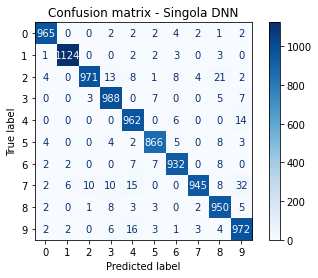

In [ ]:
# Confusion matrix DNN
predicted_images_dnn = model_dnn.predict(test_images)
predicted_labels_dnn = np.argmax(predicted_images_dnn, axis=1)

cm_dnn = confusion_matrix(test_labels, predicted_labels_dnn)
cm_fig_dnn = ConfusionMatrixDisplay(confusion_matrix=cm_dnn)

cm_fig_dnn.plot(cmap=plt.cm.Blues)
cm_fig_dnn.ax_.set_title("Confusion matrix - Singola DNN")
plt.show()

313/313 [==============================] - 1s 2ms/step


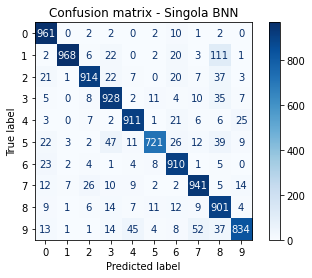

In [ ]:
predicted_images_bnn = model_bnn.predict(test_images)
predicted_labels_bnn = np.argmax(predicted_images_bnn, axis=1)

cm_bnn = confusion_matrix(test_labels, predicted_labels_bnn)
cm_fig_bnn = ConfusionMatrixDisplay(confusion_matrix=cm_bnn)

cm_fig_bnn.plot(cmap=plt.cm.Blues)
cm_fig_bnn.ax_.set_title("Confusion matrix - Singola BNN")
plt.show()

# 3. Ensemble di Binarized Neural Networks


In [3]:
# Importare anche Larq e Tensorflow all'inizio del notebook
# Scaricare dataset MNIST all'inizio del notebook

from keras.models import load_model
import numpy as np
import statistics

In [2]:
# Funzione per creazione e fitting delle reti dell'ensemble
def create_bnn_ensemble(n_models):
  kwargs = dict(input_quantizer="ste_sign",
              kernel_quantizer="ste_sign",
              kernel_constraint="weight_clip")
  
  models = list()
  for i in range(n_models):
    model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(),
    lq.layers.QuantDense(32, **kwargs, input_shape=(28, 28, 1)),
    tf.keras.layers.BatchNormalization(momentum=0.99, scale=False),
    lq.layers.QuantDense(16, **kwargs),
    tf.keras.layers.BatchNormalization(momentum=0.99, scale=False),
    lq.layers.QuantDense(10, **kwargs),
    tf.keras.layers.BatchNormalization(momentum=0.99, scale=False),
    tf.keras.layers.Activation("softmax")
    ])

    # Configurazione algoritmo di ottimizzazione, funzione di costo e metrica
    model.compile(optimizer="adam",
                loss="sparse_categorical_crossentropy",
                metrics="accuracy")
  
    # Fitting del singolo modello 
    model.fit(train_images, train_labels, batch_size=128, 
              epochs=100, validation_data=(test_images, test_labels))
  
    # Salvataggio del modello 
    filename = "ensemble_bnn" + str(i+1) + ".h5"
    model.save(filename)
    print(f"Salvataggio di {filename}\n")


# Funzione per il caricamento delle reti addestraste 
def load_bnn_ensemble(ensemble_name, n_models):
  models = list()
  for i in range(n_models):
    filename = ensemble_name + str(i+1) + ".h5"
    model = load_model(filename)
    models.append(model)
  
  return models

In [9]:
N_MODELS = 5

In [ ]:
# Creazione e fitting delle reti dell'ensemble
create_bnn_ensemble(N_MODELS)

Epoch 1/100
469/469 [==============================] - 4s 6ms/step - loss: 1.1739 - accuracy: 0.6987 - val_loss: 0.9999 - val_accuracy: 0.7693
Epoch 2/100
469/469 [==============================] - 3s 6ms/step - loss: 0.8947 - accuracy: 0.8156 - val_loss: 0.8863 - val_accuracy: 0.8345
Epoch 3/100
469/469 [==============================] - 3s 6ms/step - loss: 0.8703 - accuracy: 0.8235 - val_loss: 0.8935 - val_accuracy: 0.8272
Epoch 4/100
469/469 [==============================] - 3s 6ms/step - loss: 0.8579 - accuracy: 0.8261 - val_loss: 0.8180 - val_accuracy: 0.8405
Epoch 5/100
469/469 [==============================] - 3s 6ms/step - loss: 0.8501 - accuracy: 0.8286 - val_loss: 0.8529 - val_accuracy: 0.8318
Epoch 6/100
469/469 [==============================] - 3s 6ms/step - loss: 0.8466 - accuracy: 0.8283 - val_loss: 0.8309 - val_accuracy: 0.8400
Epoch 7/100
469/469 [==============================] - 3s 6ms/step - loss: 0.8363 - accuracy: 0.8332 - val_loss: 0.8797 - val_accuracy: 0.8172

In [10]:
# Caricamento dell'esemble
ensemble = load_bnn_ensemble("ensemble_bnn", N_MODELS)

In [11]:
# Predizioni dei singoli modelli dell'ensemble
predicted_labels = list()
for model in ensemble:
  predictions = np.argmax(model.predict(test_images), axis=1)
  predicted_labels.append(predictions)

# Majority Voting
from scipy.stats import mode

predicted_labels = np.array(predicted_labels)
predicted_labels = np.transpose(predicted_labels, (1, 0))
predicted_labels = mode(predicted_labels, axis=1)[0]
predicted_labels = np.squeeze(predicted_labels)

print(predicted_labels)

313/313 [==============================] - 1s 2ms/step
[7 2 1 ... 4 5 6]


In [13]:
# Calcolo accuratezza dell'ensemble
from sklearn.metrics import accuracy_score
ensemble_acc = accuracy_score(test_labels, predicted_labels)

print(f"Ensemble accuracy: {ensemble_acc}\n")

Ensemble accuracy: 0.8974



In [ ]:
for i in range(len(predicted_labels)):
  print(f"{predicted_labels[i] == test_labels[i]}")